<table>
  <tr>
    <td>Minería de Datos y Paradigma BigData (<b>MIN</b>) - Facultad de Informática - UCM</td>
    <td><img src="https://biblioteca.ucm.es/data/cont/media/www/pag-88746//escudo.jpg" width="110"/></td>
  </tr>
</table>

# Práctica 10 — Minería de Textos

## Mini-RAG: un buscador sobre los apuntes de la asignatura

**Pablo C. Cañizares**

No te olvides de poner vuestro nombre y puesto:



---

## Objetivo de la práctica

En esta práctica vamos a construir un **buscador sobre los PDFs de los temas de la asignatura**. La idea es responder a una pregunta sencilla pero profunda: cuando queremos *recuperar* un fragmento de los apuntes, ¿basta con buscar **palabras** o necesitamos buscar **significado**?

A lo largo de la práctica recorreremos un flujo básico de recuperación de información:

1. cargar y trocear un corpus de PDFs en fragmentos manejables;
2. construir un baseline léxico con **TF-IDF + similitud coseno**;
3. construir un buscador semántico con **embeddings de frases** (Sentence-Transformers);
4. comparar ambos enfoques en consultas reales de la asignatura;
6. combinar ambos en un buscador **híbrido** y analizar si mejora;
7. crear un RAG con un LLM básico.

Este pipeline (cargar → trocear → vectorizar → buscar → re-rankear) es exactamente el primer bloque de un sistema **RAG** (*Retrieval-Augmented Generation*): la parte de **recuperación**. 

---

## Dataset

El corpus de la práctica son los **PDFs de los temas de la asignatura**. Cada PDF se trocea por páginas y cada página se trata como un documento independiente. El número exacto de fragmentos depende de cuántos PDFs pongas en la carpeta `pdfs_asignatura/`.

A modo de prueba mínima, basta con incluir el PDF del **Tema 8 — Minería de Textos** (~62 páginas, de las cuales ~40 contienen texto extraíble). En condiciones reales puedes añadir todos los temas y la práctica funcionará igual.

---

## Columnas del DataFrame de fragmentos

Tras la carga tendremos un DataFrame `df` con un fragmento por fila y las siguientes columnas:

- **doc_id**: identificador interno del fragmento (`tema8_p012`, etc.).
- **source**: nombre del PDF de origen.
- **page**: número de página dentro del PDF.
- **text**: texto extraído de esa página, limpio de saltos de línea.
- **num_chars** / **num_words**: longitud del fragmento.

---

## Antes de empezar

Esta práctica utiliza **Sentence-Transformers** para generar embeddings. La primera ejecución descarga un modelo multilingüe pequeño (~120 MB) y deja todo cacheado. Si trabajas en un entorno sin Internet, descarga el modelo previamente.

Si no tienes las dependencias, descomenta la celda de debajo para tratar de instalarlas


### Importar librerías

In [1]:
modules = ["sentence-transformers", "pypdf", "matplotlib", "litellm"]

import sys
import os
import importlib.util
from subprocess import check_call, CalledProcessError


IMPORT_NAMES = {
    "sentence-transformers": "sentence_transformers",
}

def nombre_importable(paquete):
    """
    Convierte el nombre usado por pip en el nombre usado por import.
    Ejemplo:
    sentence-transformers -> sentence_transformers
    """

    # Quitamos extras: paquete[extra]
    nombre = paquete.split("[")[0]

    # Quitamos versión: paquete==1.2.3
    nombre = nombre.split("==")[0]

    # Casos especiales
    if nombre in IMPORT_NAMES:
        return IMPORT_NAMES[nombre]

    # Regla general
    return nombre.replace("-", "_")


def instala(modules):
    print("Instalando módulos")

    for paquete in modules:
        import_name = nombre_importable(paquete)

        encontrado = importlib.util.find_spec(import_name)

        if encontrado is not None:
            print(paquete, "encontrado")
        else:
            print(paquete, "No encontrado, instalando...", end="")

            try:
                env = os.environ.copy()

                # Muy importante en tu caso:
                # evita que pip vea rutas externas como OMNeT++ / INET
                env.pop("PYTHONPATH", None)

                # Evita el warning de la comprobación de versión de pip
                env["PIP_DISABLE_PIP_VERSION_CHECK"] = "1"

                check_call(
                    [
                        sys.executable,
                        "-m",
                        "pip",
                        "install",
                        paquete,
                    ],
                    env=env
                )

                print("¡hecho!")

            except CalledProcessError as e:
                print()
                print(f"¡Problema al instalar {paquete}!")
                print("Código de error:", e.returncode)

            except Exception as e:
                print()
                print(f"¡Problema inesperado al instalar {paquete}!")
                print("Motivo:", repr(e))

    print("¡Terminado!")


instala(modules)

Instalando módulos
sentence-transformers encontrado
pypdf encontrado
matplotlib encontrado
litellm encontrado
¡Terminado!


Ahora vamos a cargar el modelo, mientras carga, podéis ir leyendo el notebook.

In [2]:
# Embeddings semánticos
from sentence_transformers import SentenceTransformer

# Modelo multilingüe pequeño y rápido. Suficiente para una práctica.
EMBEDDING_MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"

print(f"Cargando modelo: {EMBEDDING_MODEL_NAME}")
print("(la primera vez tardará un poco porque descarga el modelo)")

embedder = SentenceTransformer(EMBEDDING_MODEL_NAME)

print(f"\nDimensión del embedding: {embedder.get_embedding_dimension()}")

C:\Users\usuario_local\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cargando modelo: paraphrase-multilingual-MiniLM-L12-v2
(la primera vez tardará un poco porque descarga el modelo)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 16582.23it/s]



Dimensión del embedding: 384


Ahora, inicializamos el resto de librerías

In [3]:
import re
import unicodedata
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from pypdf import PdfReader

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Embeddings semánticos
from sentence_transformers import SentenceTransformer

pd.set_option("display.max_colwidth", 140)


### Funciones de carga y limpieza (precargadas)

In [4]:
# Limpieza ligera de texto extraído de PDF
SPACE_RE = re.compile(r"\s+")

def normalize_for_search(text):
    """Minúsculas + sin acentos. Útil para indexación TF-IDF y para matchear consultas
    en castellano sin preocuparse de que el usuario escriba con o sin tilde."""
    if not isinstance(text, str):
        return ""
    text = text.replace("ñ", "__enie__").replace("Ñ", "__ENIE__")
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = text.replace("__enie__", "ñ").replace("__ENIE__", "ñ")
    return text.lower()


def clean_pdf_text(text):
    """Quita saltos raros del extractor de PDF y compacta espacios."""
    if not text:
        return ""
    # pypdf a veces parte palabras con guiones o introduce saltos a media línea
    text = text.replace("-\n", "").replace("\n", " ")
    text = SPACE_RE.sub(" ", text).strip()
    return text


def load_pdfs_as_pages(pdf_dir, min_chars=30):
    """Carga todos los PDFs de una carpeta y devuelve un DataFrame con un
    fragmento por página. Ignora páginas casi vacías (solo imagen, sin texto extraíble).
    """
    pdf_dir = Path(pdf_dir)
    if not pdf_dir.exists():
        raise FileNotFoundError(
            f"No existe la carpeta {pdf_dir.resolve()}. "
            "Crea una carpeta 'pdfs/' junto al notebook y mete los PDFs de los temas."
        )

    rows = []
    pdf_files = sorted(pdf_dir.glob("*.pdf"))
    if not pdf_files:
        raise FileNotFoundError(
            f"No hay PDFs en {pdf_dir.resolve()}. Añade al menos uno (p. ej. Tema_8.pdf)."
        )

    for pdf_path in pdf_files:
        try:
            reader = PdfReader(str(pdf_path))
        except Exception as e:
            print(f"[aviso] No pude leer {pdf_path.name}: {e}")
            continue

        stem = pdf_path.stem
        for page_idx, page in enumerate(reader.pages, start=1):
            try:
                raw = page.extract_text() or ""
            except Exception:
                raw = ""
            text = clean_pdf_text(raw)
            if len(text) < min_chars:
                continue  # página sin texto extraíble (típicamente solo imagen)
            rows.append({
                "doc_id": f"{stem}_p{page_idx:03d}",
                "source": pdf_path.name,
                "page":   page_idx,
                "text":   text,
            })

    if not rows:
        raise RuntimeError(
            "No se ha podido extraer texto de ninguna página. "
            "Comprueba que los PDFs no son escaneos sin OCR."
        )

    df = pd.DataFrame(rows)
    df["num_chars"] = df["text"].str.len()
    df["num_words"] = df["text"].str.split().str.len()
    return df.reset_index(drop=True)


### Stopwords en español (precargadas)

In [5]:
# Stopwords en español. Mismas que en la Práctica 9, pero sin la jerga de redes
# sociales: aquí trabajamos con material académico, no con comentarios de YouTube.
STOPWORDS_ES = {
    "a","al","algo","algunas","algunos","ante","antes","como","con","contra",
    "cual","cuando","de","del","desde","donde","durante","e","el","ella",
    "ellas","ellos","en","entre","era","erais","eran","eras","eres","es",
    "esa","esas","ese","eso","esos","esta","estaba","estabais","estaban",
    "estabas","estad","estada","estadas","estado","estados","estamos","estando",
    "estar","estaremos","estará","estarán","estarás","estaré","estaréis",
    "estaría","estaríais","estaríamos","estarían","estarías","estas","este",
    "estemos","esto","estos","estoy","está","están","fue","fueron","fui",
    "fuimos","ha","habida","habidas","habido","habidos","habiendo","habrá",
    "habrán","había","habíais","habíamos","habían","han","has","hasta","hay",
    "haya","he","hemos","la","las","le","les","lo","los","me","mi","mis",
    "mucho","muchos","muy","más","mí","nada","ni","no","nos","nosotras","nosotros",
    "nuestra","nuestras","nuestro","nuestros","o","os","otra","otras","otro",
    "otros","para","pero","poco","por","porque","que","quien","quienes","qué",
    "se","sea","seamos","sean","seas","será","serán","seré","seríais",
    "seríamos","serían","sin","sobre","sois","somos","son","soy","su","sus",
    "sí","también","tanto","te","tenga","tengamos","tengo","tiene","tienen",
    "tienes","todo","todos","tu","tus","tú","un","una","uno","unos","vosotras",
    "vosotros","vuestra","vuestras","vuestro","vuestros","y","ya","yo",
    "ser","sido","ello","cada","cuyo","cuya"
}

# Las normalizamos a minúsculas y sin acentos, igual que el corpus
STOPWORDS_NORM = sorted({normalize_for_search(w) for w in STOPWORDS_ES})
print(f"Stopwords cargadas: {len(STOPWORDS_NORM)} términos.")


Stopwords cargadas: 178 términos.


### Carga del corpus (precargada)

In [6]:
# Carga del corpus de PDFs
# Coloca los PDFs de los temas en una carpeta 'pdfs_asignatura/' junto al notebook.
candidate_dirs = [
    Path("pdfs_asignatura"),
    Path("./pdfs"),
    Path("/mnt/data/pdfs"),
]
PDF_DIR = next((p for p in candidate_dirs if p.exists()), None)
if PDF_DIR is None:
    raise FileNotFoundError(
        "No se encontró la carpeta 'pdfs_asignatura/'. Crea una y mete los PDFs de los temas."
    )

df = load_pdfs_as_pages(PDF_DIR)

print(f"Carpeta:       {PDF_DIR.resolve()}")
print(f"PDFs cargados: {df['source'].nunique()}")
print(f"Fragmentos:    {len(df)}")
print()
display(df.head(3))


Carpeta:       C:\Users\usuario_local\Downloads\pdfs_asignatura
PDFs cargados: 9
Fragmentos:    440



,doc_id,source,page,text,num_chars,num_words
0,adquisicio╠ün_p001,adquisicio╠ün.pdf,1,__ Material original por Pablo C. Cañizares __ _ _ _ Adquisición de datos Pablo C. Cañizares Minería de datos y el paradigma Big Data Ma...,220,40
1,adquisicio╠ün_p002,adquisicio╠ün.pdf,2,Índice • Introducción • XPath • BeautifulSoup • Selenium • Ejemplos 2,69,12
2,adquisicio╠ün_p003,adquisicio╠ün.pdf,3,Imágen extraídade Nashville Ciclode análisisde datos,52,6


---

## Introducción — de buscar palabras a buscar significado

Antes de empezar a escribir código, vale la pena tener clara la motivación de la práctica.

### 1. La búsqueda léxica

Cuando hacemos `Ctrl+F` en un PDF estamos haciendo **búsqueda léxica**: el sistema compara cadenas de caracteres y nos lleva a las coincidencias exactas. Es **rápido**, **predecible** y **no requiere ningún modelo entrenado**. Pero falla en cuanto la consulta del usuario no coincide literalmente con el texto:

- consulta: *«cómo reducir palabras a su forma base»*
- documento relevante: la diapositiva titulada *«Stemming y lematización»*.

No hay ni una palabra en común. La búsqueda léxica devolverá ruido.

**TF-IDF + similitud coseno** es un buscador léxico más sofisticado: pondera términos por su capacidad discriminativa y mide cuán similar es una consulta a cada documento. Sigue siendo léxico (compara palabras, no significados), pero tolera mejor el orden y la frecuencia.

### 2. La búsqueda semántica

La búsqueda semántica representa cada consulta y cada documento como un **vector denso** en un espacio donde la **cercanía geométrica refleja cercanía de significado**. Dos textos que hablan de lo mismo con palabras distintas terminan cerca; dos textos con palabras parecidas pero significados distintos pueden quedar lejos.

Estos vectores los produce un modelo de embeddings entrenado sobre grandes corpus. En esta práctica usaremos un modelo multilingüe pequeño de la familia **Sentence-Transformers** que funciona razonablemente bien con texto en castellano sin necesidad de fine-tuning.

### 3. Lo que vamos a construir

Construiremos los dos buscadores, los compararemos sobre el mismo corpus de apuntes y evaluaremos cuál recupera mejor las páginas relevantes. Después combinaremos ambos en un **buscador híbrido**: léxico + semántico. Este patrón (BM25 / TF-IDF + embeddings + re-ranking) es el estándar de facto en sistemas de búsqueda y RAG en 2026.


---

## Preparación del corpus documental

### ¿Cómo lo haremos?

1. **Inspección estructural** del DataFrame: cuántos fragmentos, de qué PDFs, qué longitud tienen.
2. **Construcción de un campo normalizado** (`text_norm`) para indexar con TF-IDF sin que las tildes nos rompan el matching.


---
### Ejercicio 1: Exploración del corpus (1 punto)

A partir del DataFrame `df` ya cargado:

1. Imprime el número de PDFs y el número total de fragmentos.
2. Para cada PDF (`source`), muestra el número de fragmentos y la longitud media en palabras.
3. Dibuja un histograma de `num_words` para ver la distribución de longitudes de fragmento.

Después, en la celda de reflexión, comenta brevemente qué te dice el histograma sobre la calidad del troceado.


In [7]:
df.head()

,doc_id,source,page,text,num_chars,num_words
0,adquisicio╠ün_p001,adquisicio╠ün.pdf,1,__ Material original por Pablo C. Cañizares __ _ _ _ Adquisición de datos Pablo C. Cañizares Minería de datos y el paradigma Big Data Ma...,220,40
1,adquisicio╠ün_p002,adquisicio╠ün.pdf,2,Índice • Introducción • XPath • BeautifulSoup • Selenium • Ejemplos 2,69,12
2,adquisicio╠ün_p003,adquisicio╠ün.pdf,3,Imágen extraídade Nashville Ciclode análisisde datos,52,6
3,adquisicio╠ün_p004,adquisicio╠ün.pdf,4,➢Ficheros accesibles a través de su propia URI → descarga directa (librería requests en Python) ➢APIs: suelen exigir identificación y de...,291,44
4,adquisicio╠ün_p006,adquisicio╠ün.pdf,6,APIs ➢Aplication Programming interface ➢Conjunto de funciones y procedimientos que permiten llamadas a determinados características de a...,318,43


Número de PDFs:      9
Número de fragmentos:  440 



,fragmentos,palabras_medias
source,,
almacenamiento.pdf,83,50.7
preprocesamiento.pdf,73,38.6
adquisicio╠ün.pdf,49,46.0
spark.pdf,46,43.2
Tema 1 - Introduccion.pdf,45,44.4
lineal.pdf,44,41.6
Tema 8 - Mineria de textos.pdf,40,80.0
frameworks.pdf,32,29.3
clustering.pdf,28,40.4


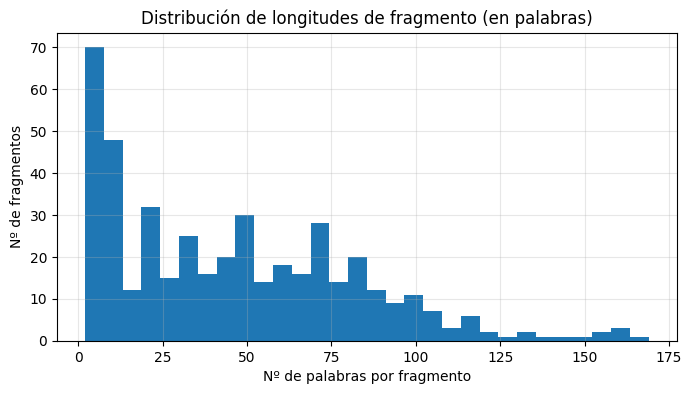

In [10]:
#solución
print(f"Número de PDFs:      {df["source"].nunique()}")
print(f"Número de fragmentos:  {len(df)} ")
print()

# Resumen por PDF
resumen_por_pdf = (
    df.groupby("source")
      .agg(fragmentos=("doc_id" , "count"),
           palabras_medias=("num_words", "mean"))
      .round(1)
      .sort_values("fragmentos", ascending=False)
)
display(resumen_por_pdf)

plt.figure(figsize=(8, 4))
df["num_words"].hist(bins=30)
plt.title("Distribución de longitudes de fragmento (en palabras)")
plt.xlabel("Nº de palabras por fragmento")
plt.ylabel("Nº de fragmentos")
plt.grid(alpha=0.3)
plt.show()


**Reflexión 1.** Observa el histograma y la tabla resumen.

1. ¿Cuál es el rango típico de longitud de un fragmento? ¿Hay fragmentos demasiado cortos (<20 palabras) o sospechosamente largos?
2. Estamos troceando **una página = un fragmento**. ¿Qué problema podría dar este criterio si un PDF fuera un libro de texto en lugar de una presentación de slides?

*Tu respuesta aquí (3-5 líneas):*
1:hay fragmentos demasiado cortos, el rango típico es de [25,75]
2:El problema es que si fuese un libro de texto, usar 1 fragmento para 1 página podría ser muy poco, pues normalmente en las diapositivas suele haber menos texto debido a que este se acompaña de una explicación oral. Para un libro habría que dividir la página en varios segmentos
...

---
### Ejercicio 2: Campo normalizado para indexación (0.5 puntos)

Crea una columna `text_norm` aplicando `normalize_for_search` sobre `text`. Esto pasa el texto a minúsculas y le quita los acentos. **Indexaremos sobre este campo y normalizaremos las consultas de la misma forma**, de modo que un usuario que escriba *«tokenizacion»* encuentre la página de *«Tokenización»*.

In [21]:
#solución
df["text_norm"]=df["text"].apply(normalize_for_search)

display(df[["doc_id", "text", "text_norm"]].head(3))


,doc_id,text,text_norm
0,adquisicio╠ün_p001,__ Material original por Pablo C. Cañizares __ _ _ _ Adquisición de datos Pablo C. Cañizares Minería de datos y el paradigma Big Data Ma...,__ material original por pablo c. cañizares __ _ _ _ adquisicion de datos pablo c. cañizares mineria de datos y el paradigma big data ma...
1,adquisicio╠ün_p002,Índice • Introducción • XPath • BeautifulSoup • Selenium • Ejemplos 2,indice • introduccion • xpath • beautifulsoup • selenium • ejemplos 2
2,adquisicio╠ün_p003,Imágen extraídade Nashville Ciclode análisisde datos,imagen extraidade nashville ciclode analisisde datos


---

## Baseline léxico con TF-IDF

### ¿Cómo lo haremos?

1. Construir un `TfidfVectorizer` sobre el campo normalizado.
2. Definir una función `buscar_tfidf(query, top_k)` que devuelve los `top_k` fragmentos más similares a una consulta usando **similitud coseno**.
3. Probar el buscador con varias consultas representativas.


---
### Ejercicio 3: Construir el índice TF-IDF (1 punto)

Construye un `TfidfVectorizer` con los siguientes parámetros y ajústalo sobre `df["text_norm"]`:

Se conserva cualquier término que aparezca al menos una vez porque el corpus es pequeño y no conviene perder vocabulario potencialmente relevante; se descartan, en cambio, los términos que aparecen en más del 95% de los documentos, ya que suelen aportar poca capacidad discriminativa. Además, se eliminan las palabras vacías previamente normalizadas, se consideran tanto palabras individuales como pares de palabras consecutivas para capturar expresiones compuestas como bag of words o tf idf, y se aplica una transformación logarítmica a la frecuencia de los términos para reducir el peso excesivo de palabras muy repetidas.
Imprime las dimensiones de la matriz resultante.


In [12]:
#solución
tfidf_vectorizer = TfidfVectorizer(min_df=1,max_df=0.95,stop_words=STOPWORDS_NORM,ngram_range=(1,2),sublinear_tf=True)
X_tfidf = tfidf_vectorizer.fit_transform(df["text_norm"])


print("=" * 60)
print("ÍNDICE TF-IDF")
print(f"Documentos:   {X_tfidf.shape[0]}")
print(f"Vocabulario:  {X_tfidf.shape[1]}")


ÍNDICE TF-IDF
Documentos:   440
Vocabulario:  15085


---
### Ejercicio 4: Función `buscar_tfidf` (1 punto)

Implementa la función:

```python
def buscar_tfidf(query, top_k=5):
    ...
```

Pasos:

1. Normaliza la consulta con `normalize_for_search`.
2. Vectorízala con `tfidf_vectorizer.transform([...])`. 
3. Calcula `cosine_similarity` entre la consulta (el resultado del paso anerior) y `X_tfidf`.
4. Devuelve un DataFrame con las columnas `["doc_id", "source", "page", "score", "preview"]` ordenado por `score` descendente, donde `preview` son los primeros 140 caracteres del fragmento.

Pruébala con la consulta `"qué es la tokenización"`.


In [13]:
#solución
def buscar_tfidf(query, top_k=5):
    q_norm = normalize_for_search(query)
    q_vec  = tfidf_vectorizer.transform([q_norm])
    
    sims   = cosine_similarity(q_vec,X_tfidf).ravel()
    top_idx = np.argsort(-sims)[:top_k]

    out = df.iloc[top_idx][["doc_id", "source", "page"]].copy()
    out["score"]   = sims[top_idx].round(4)
    out["preview"] = df.iloc[top_idx]["text"].str.slice(0, 140) + "…"
    return out.reset_index(drop=True)


print("Consulta: 'qué es la tokenización'")
display(buscar_tfidf("qué es la tokenización", top_k=5))


Consulta: 'qué es la tokenización'


,doc_id,source,page,score,preview
0,Tema 8 - Mineria de textos_p012,Tema 8 - Mineria de textos.pdf,12,0.0971,Preprocesado: Tokenización • Tokenizar es dividir el texto en unidades manejables llamadas tokens. • Los niveles más habituales: palabra...
1,Tema 8 - Mineria de textos_p010,Tema 8 - Mineria de textos.pdf,10,0.0841,"01 Recolección Fuentes de datos estructuradas y no estructuradas. web, APIs, corpus › 02 Limpieza Eliminación de ruido, etiquetas HTML, ..."
2,Tema 8 - Mineria de textos_p041,Tema 8 - Mineria de textos.pdf,41,0.0000,"Topic Modeling: Descubrir temas latentes • Cada documento se modela como una mezcla de temas. • Cada tema, como una distribución de pala..."
3,Tema 8 - Mineria de textos_p040,Tema 8 - Mineria de textos.pdf,40,0.0000,Clustering de documentos Agrupar documentos similares sin etiquetas previas. Es un problema no supervisado. K-Means • Divide en k grupos...
4,Tema 8 - Mineria de textos_p039,Tema 8 - Mineria de textos.pdf,39,0.0000,Clasificación: de textos Asignar cada documento a una categoría predefinida a partir de ejemplos etiquetados. Es un problema supervisado...


---
### Ejercicio 5: Probar el buscador léxico con varias consultas (1 punto)

Lanza `buscar_tfidf` con las siguientes consultas y comenta brevemente cuál recupera bien y cuál falla:

- `"TF-IDF"`
- `"bag of words"`
- `"cómo reducir palabras a su forma base"`
- `"agrupar documentos parecidos sin etiquetas"`


In [19]:
#solución
queries_demo = [
    "TF_IDF",
    "bag of words",
    "cómo reducir palabras a su forma base",
    "agrupar documentos parecidos sin etiquetas"
]

for q in queries_demo:
    print("-" * 70)
    print(f"Consulta: {q!r}")
    display(buscar_tfidf(q))


----------------------------------------------------------------------
Consulta: 'TF_IDF'


,doc_id,source,page,score,preview
0,adquisicio╠ün_p001,adquisicio╠ün.pdf,1,0.0,__ Material original por Pablo C. Cañizares __ _ _ _ Adquisición de datos Pablo C. Cañizares Minería de datos y el paradigma Big Data Ma...
1,adquisicio╠ün_p002,adquisicio╠ün.pdf,2,0.0,Índice • Introducción • XPath • BeautifulSoup • Selenium • Ejemplos 2…
2,adquisicio╠ün_p003,adquisicio╠ün.pdf,3,0.0,Imágen extraídade Nashville Ciclode análisisde datos…
3,adquisicio╠ün_p004,adquisicio╠ün.pdf,4,0.0,➢Ficheros accesibles a través de su propia URI → descarga directa (librería requests en Python) ➢APIs: suelen exigir identificación y de...
4,adquisicio╠ün_p006,adquisicio╠ün.pdf,6,0.0,APIs ➢Aplication Programming interface ➢Conjunto de funciones y procedimientos que permiten llamadas a determinados características de a...


----------------------------------------------------------------------
Consulta: 'bag of words'


,doc_id,source,page,score,preview
0,Tema 8 - Mineria de textos_p018,Tema 8 - Mineria de textos.pdf,18,0.3482,Representación: Bag of Words • Se construye un vocabulario global con los términos únicos del corpus. • Cada posición del vector indica ...
1,Tema 8 - Mineria de textos_p017,Tema 8 - Mineria de textos.pdf,17,0.1842,"Representación: del texto al vector Una vez preprocesado el texto, necesitamos transformarlo en números. Representaciones clásicas • Bag..."
2,spark_p026,spark.pdf,26,0.0684,"Ejemplo : reduceByKey # reduceByKey — agrega valores por clave (ANTES del shuffle) words = sc.parallelize([""hola"", ""mundo"", ""hola"", ""spa..."
3,spark_p041,spark.pdf,41,0.0350,"Rendimiento en la práctica Benchmark: Group-By sobre 1.000 millones de filas (MacBook M1, 64 GB RAM) pandas on Spark 62s Sin optimizació..."
4,adquisicio╠ün_p008,adquisicio╠ün.pdf,8,0.0346,POST /customers/:customer_id/deliveries GET /customers/:customer_id/deliveries?filter=<string>&limit=<integer>&offset=<integer> POST /cu...


----------------------------------------------------------------------
Consulta: 'cómo reducir palabras a su forma base'


,doc_id,source,page,score,preview
0,almacenamiento_p013,almacenamiento.pdf,13,0.1059,OLAP: cómo funciona? 15 Base de datos relacional Cubo OLAP…
1,almacenamiento_p044,almacenamiento.pdf,44,0.1005,MongoDB: Conexión 49 Conexión desde shell a la base de datos con mongosh:…
2,preprocesamiento_p081,preprocesamiento.pdf,81,0.0781,Minería de datos y Paradigma BigData - Pablo C. Cañizares Problema dimensionalidad • Convertir virtud en problema • Demasiados datos • P...
3,Tema 1 - Introduccion_p046,Tema 1 - Introduccion.pdf,46,0.0711,Casos de éxito (I) 47 ¿Podemos tasar de forma automática una propiedad?…
4,Tema 1 - Introduccion_p047,Tema 1 - Introduccion.pdf,47,0.0707,Casos de éxito (I) 48 ¿Podemos tasar de forma automática una propiedad?…


----------------------------------------------------------------------
Consulta: 'agrupar documentos parecidos sin etiquetas'


,doc_id,source,page,score,preview
0,Tema 8 - Mineria de textos_p040,Tema 8 - Mineria de textos.pdf,40,0.1718,Clustering de documentos Agrupar documentos similares sin etiquetas previas. Es un problema no supervisado. K-Means • Divide en k grupos...
1,Tema 8 - Mineria de textos_p038,Tema 8 - Mineria de textos.pdf,38,0.1636,Tareas principales en Text Mining Lo que se puede hacer una vez preprocesado y analizado el texto. Clasificación asignar cada documento ...
2,Tema 8 - Mineria de textos_p006,Tema 8 - Mineria de textos.pdf,6,0.1171,">80 % de los datos generados cada día son textuales • Empresas, gobiernos y universidades almacenan volúmenes masivos de texto. • El aná..."
3,clustering_p003,clustering.pdf,3,0.1054,Algunas aplicaciones de clustering Segmentación de mercados: agrupar clientes con características similares Análisis de redes sociales: ...
4,almacenamiento_p084,almacenamiento.pdf,84,0.1023,"89 MongoDB: Agrupaciones, $unwind Es el reverso de $push; cuando tenemos documentos que contienen un array y queremos agrupar por valore..."


**Reflexión.** Mira los resultados de las cuatro consultas anteriores.

1. ¿En cuáles funciona TF-IDF razonablemente bien?
2. ¿En cuáles falla y por qué?

*Tu respuesta aquí (3-5 líneas):*

#solución

1:en las 2 primeras, en TF_IDF y en bag of words. Porque se basa en coincidencias exactas


2:En como deducir palabras asociadas, porque lo que hace es buscar la frase exacta
.

---

## Búsqueda semántica con embeddings

### ¿Cómo lo haremos?

1. Cargar un modelo de **Sentence-Transformers** multilingüe.
2. Codificar todos los fragmentos del corpus en vectores densos (una sola vez).
3. Definir `buscar_embeddings(query, top_k)` que codifica la consulta y devuelve los `top_k` fragmentos por similitud coseno en el espacio de embeddings.

> **Nota técnica.** Usamos `paraphrase-multilingual-MiniLM-L12-v2`: un modelo pequeño (~120 MB) entrenado en >50 idiomas. La primera ejecución descarga el modelo; luego va en caché.


---
### Ejercicio 6: Calcular embeddings del corpus (1 punto)

1. Codifica todos los textos de `df["text"]` en una matriz `X_emb` con `embedder.encode(...)`. Pasa `convert_to_numpy=True`, `normalize_embeddings=True` y `show_progress_bar=True`. El método encode no permite la entrada de Series, para procesar todo el dataset utiliza el método .tolist() para proporcionarselo como lista.
2. Imprime las dimensiones de la matriz resultante.

> **¿Por qué `normalize_embeddings=True`?** Porque al normalizar a norma 1, la **similitud coseno** entre dos vectores se reduce a su producto escalar, lo que nos permite calcularla con una simple multiplicación de matrices.

> **Importante**: pasa `df["text"]` (texto original), **no** `df["text_norm"]`. Los modelos de embeddings se entrenan sobre texto natural, con tildes y mayúsculas. Quitarles esa información los confunde.


In [22]:
#solución
X_emb = embedder.encode(
    df["text"].tolist(),
    convert_to_numpy=True,
    normalize_embeddings=True, 
    show_progress_bar=True
) 

print(f"Matriz de embeddings: {X_emb.shape}")
print(f"Norma media:          {np.linalg.norm(X_emb, axis=1).mean():.4f}  (debe ser ~1.0)")


Batches: 100%|██████████| 14/14 [00:03<00:00,  4.40it/s]

Matriz de embeddings: (440, 384)
Norma media:          1.0000  (debe ser ~1.0)


---
### Ejercicio 7: Función `buscar_embeddings` (1 punto)

Implementa `buscar_embeddings(query, top_k=5)` con la misma firma de salida que `buscar_tfidf`:

1. Codifica la consulta con `embedder.encode([...], normalize_embeddings=True)`.
2. Como `X_emb` está normalizada, la similitud coseno = producto escalar: `sims = X_emb @ q_vec.T`.
3. Devuelve un DataFrame con `["doc_id", "source", "page", "score", "preview"]` ordenado por `score` desc.

Pruébala con `"cómo reducir palabras a su forma base"` (la consulta donde TF-IDF fallaba).


In [25]:
#solución
def buscar_embeddings(query, top_k=5):
    q_vec = embedder.encode([query], normalize_embeddings=True)[0]

    sims= X_emb @ q_vec.T
    top_idx = np.argsort(-sims)[:top_k]

    out = df.iloc[top_idx][["doc_id", "source", "page"]].copy()
    out["score"]   = sims[top_idx].round(4)
    out["preview"] = df.iloc[top_idx]["text"].str.slice(0, 140) + "…"
    return out.reset_index(drop=True)

print("Consulta: 'cómo reducir palabras a su forma base'")
display(buscar_embeddings("cómo reducir palabras a su forma base", top_k=5))


Consulta: 'cómo reducir palabras a su forma base'


,doc_id,source,page,score,preview
0,Tema 8 - Mineria de textos_p015,Tema 8 - Mineria de textos.pdf,15,0.6346,"Preprocesado: Stemming y lematización Ambos reducen variantes morfológicas de una palabra, pero con enfoques distintos. Stemming • Métod..."
1,Tema 8 - Mineria de textos_p014,Tema 8 - Mineria de textos.pdf,14,0.5496,Preprocesado: Stopwords Las stopwords son palabras muy frecuentes con poca capacidad discriminativa en muchas tareas. Ejemplos en españo...
2,Tema 8 - Mineria de textos_p028,Tema 8 - Mineria de textos.pdf,28,0.5208,Embeddings: representaciones densas • Aprende de grandes corpus la distribución contextual de los términos. • Palabras de significado si...
3,Tema 8 - Mineria de textos_p017,Tema 8 - Mineria de textos.pdf,17,0.5073,"Representación: del texto al vector Una vez preprocesado el texto, necesitamos transformarlo en números. Representaciones clásicas • Bag..."
4,spark_p026,spark.pdf,26,0.4704,"Ejemplo : reduceByKey # reduceByKey — agrega valores por clave (ANTES del shuffle) words = sc.parallelize([""hola"", ""mundo"", ""hola"", ""spa..."


---

## Comparación cualitativa

Antes de medir métricas vamos a mirar resultados con los ojos. Vamos a preparar un conjunto de consultas de tres tipos:

- **Léxicas puras**: la consulta contiene casi literalmente la palabra clave del documento. Aquí TF-IDF debería ganar o empatar.
- **Semánticas**: la consulta describe el concepto con otras palabras. Aquí los embeddings deberían ganar.
- **Híbridas / ambiguas**: la consulta tiene tanto pista léxica como semántica. Resultado a priori menos predecible.


---
### Ejercicio 8. Comparativa lado a lado (1 punto)

Ejecuta la siguiente celda, y responde a las preguntas.

```python
queries_eval = [
    # léxicas
    "TF-IDF",
    "BERT vs GPT",
    # semánticas
    "cómo reducir palabras a su forma base",
    "agrupar documentos parecidos sin etiquetas",
    "extraer personas y lugares de un texto",
    # híbrida
    "una palabra puede tener varios significados",
]
```


In [26]:
#solución
def comparar(query, top_k=3):
    print("=" * 70)
    print(f"Consulta: {query!r}")
    print("=" * 70)
    print("\n→ TF-IDF")
    display(buscar_tfidf(query,top_k=top_k))
    print("\n→ Embeddings")
    display(buscar_embeddings(query,top_k=top_k))


queries_eval = [
    # léxicas
    "TF-IDF",
    "BERT vs GPT",
    # semánticas
    "cómo reducir palabras a su forma base",
    "agrupar documentos parecidos sin etiquetas",
    "extraer personas y lugares de un texto",
    # híbrida
    "una palabra puede tener varios significados",
]

for q in queries_eval:
    comparar(q, top_k=3)


Consulta: 'TF-IDF'

→ TF-IDF


,doc_id,source,page,score,preview
0,Tema 8 - Mineria de textos_p021,Tema 8 - Mineria de textos.pdf,21,0.3937,"Representación: TF-IDF TF-IDF representa cada documento como un vector de pesos de palabras, donde cada peso refleja la frecuencia de un..."
1,Tema 8 - Mineria de textos_p023,Tema 8 - Mineria de textos.pdf,23,0.3225,TF-IDF: Ejemplo Supongamos dos términos candidatos para caracterizar un documento. Término: universidad Aparece en casi todos los docume...
2,Tema 8 - Mineria de textos_p022,Tema 8 - Mineria de textos.pdf,22,0.2489,"Representación: TF-IDF Intuición • Una palabra importante en un documento debe pesar más. • Si aparece en casi todos los documentos , su..."



→ Embeddings


,doc_id,source,page,score,preview
0,Tema 8 - Mineria de textos_p023,Tema 8 - Mineria de textos.pdf,23,0.7661,TF-IDF: Ejemplo Supongamos dos términos candidatos para caracterizar un documento. Término: universidad Aparece en casi todos los docume...
1,Tema 8 - Mineria de textos_p022,Tema 8 - Mineria de textos.pdf,22,0.6292,"Representación: TF-IDF Intuición • Una palabra importante en un documento debe pesar más. • Si aparece en casi todos los documentos , su..."
2,Tema 8 - Mineria de textos_p021,Tema 8 - Mineria de textos.pdf,21,0.6222,"Representación: TF-IDF TF-IDF representa cada documento como un vector de pesos de palabras, donde cada peso refleja la frecuencia de un..."


Consulta: 'BERT vs GPT'

→ TF-IDF


...

,doc_id,source,page,score,preview
0,Tema 8 - Mineria de textos_p004,Tema 8 - Mineria de textos.pdf,4,0.6107,"Text mining Extracción de información útil, patrones y conocimiento a partir de grandes colecciones de documentos de forma automática 4…"
1,Tema 8 - Mineria de textos_p061,Tema 8 - Mineria de textos.pdf,61,0.5955,Minería de textos: Ejemplo práctico Vamos al notebook: Minería de textos…
2,Tema 8 - Mineria de textos_p038,Tema 8 - Mineria de textos.pdf,38,0.5663,Tareas principales en Text Mining Lo que se puede hacer una vez preprocesado y analizado el texto. Clasificación asignar cada documento ...


Consulta: 'una palabra puede tener varios significados'

→ TF-IDF


,doc_id,source,page,score,preview
0,Tema 8 - Mineria de textos_p009,Tema 8 - Mineria de textos.pdf,9,0.1322,"Retos: el texto como dato El lenguaje es ambiguo, variable y dependiente del contexto. 1 Ambigüedad léxica: Una palabra, varios signific..."
1,preprocesamiento_p038,preprocesamiento.pdf,38,0.1071,Duplicados • Los datos redundantes suelen aparecer a menudo cuando se integran múltiples fuentes de datos. • El mismo atributo puede ten...
2,Tema 8 - Mineria de textos_p033,Tema 8 - Mineria de textos.pdf,33,0.0656,"Embeddings contextuales y transformers Una palabra, varios vectores • Los embeddings clásicos asignan un único vector a cada palabra, si..."



→ Embeddings


,doc_id,source,page,score,preview
0,Tema 8 - Mineria de textos_p009,Tema 8 - Mineria de textos.pdf,9,0.5071,"Retos: el texto como dato El lenguaje es ambiguo, variable y dependiente del contexto. 1 Ambigüedad léxica: Una palabra, varios signific..."
1,Tema 8 - Mineria de textos_p024,Tema 8 - Mineria de textos.pdf,24,0.4894,"Representaciones clásicas: limitaciones BoW y TF-IDF funcionan, pero tienen problemas estructurales. Alta dimensionalidad El vocabulario..."
2,Tema 8 - Mineria de textos_p014,Tema 8 - Mineria de textos.pdf,14,0.4779,Preprocesado: Stopwords Las stopwords son palabras muy frecuentes con poca capacidad discriminativa en muchas tareas. Ejemplos en españo...


**Reflexión.** Mira las seis comparativas anteriores.

1. Cita una consulta donde **TF-IDF gane claramente** (el top-1 es relevante en TF-IDF y no en embeddings, o lo es con score mucho menor).
2. Cita dos consultas donde **embeddings gane claramente**.
3. ¿Hay alguna consulta donde **ambos fallen**? ¿A qué crees que se debe?

*Tu respuesta aquí (4-6 líneas, en total):*

In [30]:
# :Consulta: 'BERT vs GPT'

# 2:Consulta: 'cómo reducir palabras a su forma base' y Consulta: 'extraer personas y lugares de un texto'

# 3:

#solución


### Ejercicio 9 Método híbrído (2 puntos). 
Hemos visto la eficacia de los dos métodos, y la conclusión es clara: hay ocasiones en las que es mejor buscar por similutud sintáctica y otras por similitud semática. Por ello, vamos a crear un método que utilice lo mejor de los dos mundos.

In [27]:
#solución
def normalizar_scores(scores):
    """
    Normaliza un vector de scores al rango [0, 1].
    Si todos los valores son iguales, devuelve ceros.
    """
    scores = np.asarray(scores, dtype=float)
    minimo = scores.min()
    maximo = scores.max()

    if maximo == minimo:
        return np.zeros_like(scores)

    return (scores - minimo) / (maximo - minimo)


def buscar_hibrido_full(query, top_k=5, alpha=0.5):
    """
    Recupera chunks combinando TF-IDF y embeddings.

    alpha controla el peso semántico:
      alpha = 0.0  -> solo TF-IDF
      alpha = 1.0  -> solo embeddings
      alpha = 0.3  -> 30% embeddings, 70% TF-IDF

    Para preguntas con términos técnicos exactos, conviene dar más peso a TF-IDF.
    """
    
    
    # Score TF-IDF (normaliza, transforma con el TFIDF, y calcula la cosine similarity)
    q_norm =  normalize_for_search(query)
    q_tfidf =  tfidf_vectorizer.transform([q_norm])
    scores_tfidf = cosine_similarity(q_tfidf,X_tfidf).ravel()

    # Score embeddings (calculamos los embeddings por query y la similaridad)
    q_emb = embedder.encode([query], normalize_embeddings=True)[0]
    scores_emb = X_emb @ q_emb.T


    # Normalización (de ambos scores)
    scores_tfidf_norm = normalizar_scores(scores_tfidf)
    scores_emb_norm = normalizar_scores(scores_emb)

    # Combinación híbrida (1-alpha *  TFIDF + alpha * EMB)
    scores_hibridos = (
        (1-alpha * scores_tfidf_norm  + alpha * scores_emb_norm)
    )

    # Ranking final
    top_idx = np.argsort(-scores_hibridos)[:top_k]

    out = df.iloc[top_idx][["doc_id", "source", "page", "text"]].copy()
    out["score_hibrido"] = scores_hibridos[top_idx].round(4)
    out["score_tfidf"] = scores_tfidf_norm[top_idx].round(4)
    out["score_emb"] = scores_emb_norm[top_idx].round(4)
    out["preview"] = out["text"].str.slice(0, 180) + "…"

    return out.reset_index(drop=True)

In [28]:
#Para probar
def comparar(query, top_k=3):
    print("=" * 70)
    print(f"Consulta: {query!r}")
    print("\n→ TF-IDF")
    display(buscar_tfidf(query, top_k=top_k))
    print("\n→ Embeddings")
    display(buscar_embeddings(query, top_k=top_k))
    print("\n→ Mixture")
    display(buscar_hibrido_full(query, top_k=top_k, alpha=0.30))


queries_eval = [
    # léxicas
    "TF-IDF",
    "BERT vs GPT",
    # semánticas
    "cómo reducir palabras a su forma base",
    "agrupar documentos parecidos sin etiquetas",
    "extraer personas y lugares de un texto",
    # híbrida
    "una palabra puede tener varios significados",
]

for q in queries_eval:
    comparar(q, top_k=3)


Consulta: 'TF-IDF'

→ TF-IDF


,doc_id,source,page,score,preview
0,Tema 8 - Mineria de textos_p021,Tema 8 - Mineria de textos.pdf,21,0.3937,"Representación: TF-IDF TF-IDF representa cada documento como un vector de pesos de palabras, donde cada peso refleja la frecuencia de un..."
1,Tema 8 - Mineria de textos_p023,Tema 8 - Mineria de textos.pdf,23,0.3225,TF-IDF: Ejemplo Supongamos dos términos candidatos para caracterizar un documento. Término: universidad Aparece en casi todos los docume...
2,Tema 8 - Mineria de textos_p022,Tema 8 - Mineria de textos.pdf,22,0.2489,"Representación: TF-IDF Intuición • Una palabra importante en un documento debe pesar más. • Si aparece en casi todos los documentos , su..."



→ Embeddings


,doc_id,source,page,score,preview
0,Tema 8 - Mineria de textos_p023,Tema 8 - Mineria de textos.pdf,23,0.7661,TF-IDF: Ejemplo Supongamos dos términos candidatos para caracterizar un documento. Término: universidad Aparece en casi todos los docume...
1,Tema 8 - Mineria de textos_p022,Tema 8 - Mineria de textos.pdf,22,0.6292,"Representación: TF-IDF Intuición • Una palabra importante en un documento debe pesar más. • Si aparece en casi todos los documentos , su..."
2,Tema 8 - Mineria de textos_p021,Tema 8 - Mineria de textos.pdf,21,0.6222,"Representación: TF-IDF TF-IDF representa cada documento como un vector de pesos de palabras, donde cada peso refleja la frecuencia de un..."



→ Mixture


...

,doc_id,source,page,score,preview
0,Tema 8 - Mineria de textos_p009,Tema 8 - Mineria de textos.pdf,9,0.1322,"Retos: el texto como dato El lenguaje es ambiguo, variable y dependiente del contexto. 1 Ambigüedad léxica: Una palabra, varios signific..."
1,preprocesamiento_p038,preprocesamiento.pdf,38,0.1071,Duplicados • Los datos redundantes suelen aparecer a menudo cuando se integran múltiples fuentes de datos. • El mismo atributo puede ten...
2,Tema 8 - Mineria de textos_p033,Tema 8 - Mineria de textos.pdf,33,0.0656,"Embeddings contextuales y transformers Una palabra, varios vectores • Los embeddings clásicos asignan un único vector a cada palabra, si..."



→ Embeddings


,doc_id,source,page,score,preview
0,Tema 8 - Mineria de textos_p009,Tema 8 - Mineria de textos.pdf,9,0.5071,"Retos: el texto como dato El lenguaje es ambiguo, variable y dependiente del contexto. 1 Ambigüedad léxica: Una palabra, varios signific..."
1,Tema 8 - Mineria de textos_p024,Tema 8 - Mineria de textos.pdf,24,0.4894,"Representaciones clásicas: limitaciones BoW y TF-IDF funcionan, pero tienen problemas estructurales. Alta dimensionalidad El vocabulario..."
2,Tema 8 - Mineria de textos_p014,Tema 8 - Mineria de textos.pdf,14,0.4779,Preprocesado: Stopwords Las stopwords son palabras muy frecuentes con poca capacidad discriminativa en muchas tareas. Ejemplos en españo...



→ Mixture


,doc_id,source,page,text,score_hibrido,score_tfidf,score_emb,preview
0,Tema 8 - Mineria de textos_p014,Tema 8 - Mineria de textos.pdf,14,Preprocesado: Stopwords Las stopwords son palabras muy frecuentes con poca capacidad discriminativa en muchas tareas. Ejemplos en españo...,1.2861,0.0000,0.9536,Preprocesado: Stopwords Las stopwords son palabras muy frecuentes con poca capacidad discriminativa en muchas tareas. Ejemplos en españo...
1,Tema 8 - Mineria de textos_p028,Tema 8 - Mineria de textos.pdf,28,Embeddings: representaciones densas • Aprende de grandes corpus la distribución contextual de los términos. • Palabras de significado si...,1.2541,0.1033,0.9503,Embeddings: representaciones densas • Aprende de grandes corpus la distribución contextual de los términos. • Palabras de significado si...
2,Tema 8 - Mineria de textos_p007,Tema 8 - Mineria de textos.pdf,7,"La calidad, el estilo y el nivel de ruido cambian mucho según el dominio. Noticias : muy informal, abreviaturas, emojis, hashtags Reseña...",1.2402,0.0000,0.8006,"La calidad, el estilo y el nivel de ruido cambian mucho según el dominio. Noticias : muy informal, abreviaturas, emojis, hashtags Reseña..."


---

## Easter Egg — del retriever al RAG completo (Ejercicio extra)

> **Nota**: esta parte es **opcional** y no tiene valor sobre la nota de la práctica, pero es un caso de uso hot topic en la actualidad. Construye un RAG completo conectando el buscador híbrido a un LLM externo.

Hasta ahora hemos construido la pieza dura de un sistema RAG: la **recuperación**. Devolvemos los `top_k` fragmentos más relevantes para una consulta, los podemos evaluar con MRR y los podemos combinar léxico+semántico. Pero el usuario final no quiere leer fragmentos: quiere una **respuesta en lenguaje natural** que sintetice esos fragmentos.

Eso es lo que añade la **G** de RAG (*Retrieval-Augmented Generation*): un **Large Language Model** que recibe la pregunta del usuario más los fragmentos recuperados y produce una respuesta.

### Anatomía de un RAG

```
        ┌──────────────┐     ┌────────────────┐     ┌──────────────┐
query ─►│  RETRIEVE    │────►│   AUGMENT      │────►│   GENERATE   │─► answer
        │ (Parte 7:    │     │ (formatear el  │     │     LLM      │
        │  buscador    │     │  prompt con    │     │              │
        │  híbrido)    │     │  los chunks)   │     │              │
        └──────────────┘     └────────────────┘     └──────────────┘
```

Los tres pasos son:

1. **Retrieve**: obtener los chunks relevantes con nuestro buscador híbrido (ya lo tenemos hecho).
2. **Augment**: construir un prompt que inyecte los chunks como contexto y le pida al LLM responder usando solo ese contexto.
3. **Generate**: llamar al LLM con ese prompt y devolver la respuesta.

### Por qué `temperature=0`

Para RAG queremos que el LLM sea **fiel al contexto**, no creativo. Con `temperature=0` el modelo elige siempre el siguiente token más probable y reproduce el contexto con menos variación. Con `temperature=0.7` (default de muchos proveedores) el modelo se aleja del contexto, parafrasea con más libertad y, cuando el contexto no tiene la respuesta, **alucina** con más frecuencia.

### Por qué pedir citas

Si el LLM no cita de qué fragmento sale cada afirmación, no podemos auditar la respuesta. Pedirle explícitamente que use `[doc_id]` cuando use información de un chunk hace la respuesta **trazable**: el usuario puede comprobar la fuente original. Es la diferencia entre un RAG juguete y un RAG que se puede usar con datos serios.

### Sobre el LLM

Vamos a usar **Cerebras Cloud** (Llama 3.3 70B) vía **LiteLLM**. Cerebras tiene tier gratuito generoso (1M tokens/día) y LiteLLM nos da una interfaz uniforme: si mañana cambias a Groq, OpenAI o Anthropic, solo cambias la cadena del modelo.

Si no tienes clave API, no pasa nada: la práctica detecta su ausencia y entra en **modo simulado**. Verás los prompts construidos pero no la respuesta real del LLM. Lo importante pedagógicamente — *qué se le pasa al modelo* — lo verás igual.


### Configuración del LLM (precargada)

In [ ]:
# Esta celda solo comprueba que está disponible y, si falta, lo instala.

import sys
import subprocess

try:
    import litellm
    print("LiteLLM disponible:", getattr(litellm, "__version__", "versión no indicada"))
except ImportError:
    print("LiteLLM no está instalado. Instalando...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "litellm"
    ])
    print("LiteLLM instalado. Reinicia el kernel si el import sigue fallando.")

In [ ]:
# Instalación (descomentar la primera vez):
#!pip install litellm

import os
from litellm import completion

# Configuración del modelo (puedes cambiarlo por otro de los gratuitos)
LLM_MODEL = "cerebras/llama3.1-8b"

# Tu clave API
# Descomenta y pega aquí tu clave (NO subas el notebook a git con la clave dentro)
#os.environ["CEREBRAS_API_KEY"] = "csk..."

def _llm_provider_disponible():
    """Devuelve el nombre del proveedor cuya API key está disponible, o None."""
    if os.getenv("CEREBRAS_API_KEY") and LLM_MODEL.startswith("cerebras/"):
        return "cerebras"
    if os.getenv("GROQ_API_KEY") and LLM_MODEL.startswith("groq/"):
        return "groq"
    if os.getenv("ANTHROPIC_API_KEY") and LLM_MODEL.startswith("anthropic/"):
        return "anthropic"
    if os.getenv("OPENAI_API_KEY") and LLM_MODEL.startswith("openai/"):
        return "openai"
    return None


def llm_completar(messages, temperature=0.0, max_tokens=600):
    """Wrapper sobre litellm.completion con manejo de errores y modo simulado.

    Si no hay API key disponible, devuelve un mensaje indicativo en lugar de fallar.
    Esto permite ejecutar la práctica sin clave para inspeccionar los prompts.
    """
    provider = _llm_provider_disponible()
    if provider is None:
        return (
            "[MODO SIMULADO — no se ha definido API key]\n"
            "Define CEREBRAS_API_KEY (o GROQ_API_KEY / ANTHROPIC_API_KEY) y vuelve a "
            "ejecutar para ver la respuesta real del LLM. "
            "Mientras tanto, el prompt enviado al modelo es el que se imprime arriba."
        )

    try:
        response = completion(
            model=LLM_MODEL,
            messages=messages,
            temperature=temperature,
            max_tokens=max_tokens,
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"[ERROR llamando al LLM: {type(e).__name__}: {e}]"


# Verificación de configuración
provider = _llm_provider_disponible()
if provider:
    print(f"LLM configurado: {LLM_MODEL}  (proveedor: {provider})")
else:
    print("Sin API key detectada — el notebook funcionará en MODO SIMULADO.")
    print("Verás los prompts construidos, pero no la respuesta real del LLM.")


---
### Ejercicio 10: Construir el prompt RAG

Implementa la función:

```python
def format_rag_prompt(query, chunks_df):
    """Construye los messages para el LLM a partir de la consulta y los chunks recuperados.

    Devuelve una lista [{"role": "system", ...}, {"role": "user", ...}].
    """
```

**Especificación:**

1. El **mensaje system** debe pedir al LLM:
   - Que responda **únicamente** con información presente en el contexto.
   - Que **cite** los fragmentos que use con su `doc_id` entre corchetes (p. ej. `[Tema_8_p015]`).
   - Que si la respuesta no está en el contexto, diga literalmente: *«No tengo esa información en los apuntes proporcionados.»*
2. El **mensaje user** debe contener:
   - Un bloque `CONTEXTO:` con cada chunk numerado, precedido de su `doc_id` y su `page` para que el LLM pueda citarlo.
   - La pregunta del usuario etiquetada como `PREGUNTA:`.

Después, **muestra el prompt** para la consulta `"¿Cuál es la diferencia entre stemming y lematización?"` (3 chunks recuperados con el híbrido). **No llames al LLM todavía**: el objetivo es ver con tus ojos qué se le va a pasar.


In [ ]:
#solución
def format_rag_prompt(query, chunks_df):
    """Construye los messages para el LLM a partir de la consulta y los chunks recuperados."""
    # Construir el bloque de contexto
    bloques = []
    for _, row in chunks_df.iterrows():
        bloques.append(f"[{row['doc_id']}] (página {row['page']})")
        bloques.append(row.get("text", row.get("preview", "")))
        bloques.append("")  # línea en blanco entre chunks
    contexto = "\n".join(bloques).strip()

    system = (
        "Eres un asistente que responde preguntas sobre los apuntes de la asignatura "
        "Minería de Datos y Paradigma BigData. "
        "Resto de instrucciones ..."
    )

    user = f"CONTEXTO:\n{contexto}\n\nPREGUNTA: {query}"

    return [
        {"role": "system", "content": system},
        {"role": "user",   "content": user},
    ]


# Importante: para que el LLM pueda leer los chunks completos, necesitamos
# acceder al texto íntegro y no al preview truncado. Reescribimos brevemente
# el resultado de buscar_hibrido para incluir text completo en lugar de preview.
# Importante: para que el LLM pueda leer los chunks completos,
# añadimos el texto íntegro al resultado del buscador.
def buscar_rag_full(query, top_k=3, alpha=0.25):
    """
    Recupera chunks para el Mini-RAG usando el buscador semántico.

    Invocar al método de búsqueda implementado en el ejercicio anterior (buscador hibrído)
    """
    res = ...

    # Si buscar_embeddings ya trae text, no hace falta mergear.
    # Si solo trae preview, añadimos el texto completo desde df.
    if "text" not in res.columns:
        res = res.merge(
            df[["doc_id", "text"]],
            on="doc_id",
            how="left"
        )

    return res


# Inspeccionar el prompt para una consulta de ejemplo
demo_query = "¿Cuál es la diferencia entre stemming y lematización?"
demo_chunks = buscar_rag_full(demo_query, top_k=3, alpha=0.25)

print(f"Chunks recuperados para: {demo_query!r}")
display(demo_chunks[["doc_id", "page", "score_hibrido", "score_tfidf", "score_emb", "preview"]])

messages = format_rag_prompt(demo_query, demo_chunks)
print("\n" + "=" * 70)
print("MENSAJE SYSTEM")
print("=" * 70)
print(messages[0]["content"])
print("\n" + "=" * 70)
print("MENSAJE USER")
print("=" * 70)
print(messages[1]["content"][:2000])


**Pregunta.** Mira el prompt que acabas de construir.

1. ¿Por qué incluimos el `doc_id` antes de cada chunk en el contexto?
2. ¿Qué pasaría si en el system prompt **no** le dijéramos al LLM que responda *solo* con el contexto?

*Tu respuesta aquí (2-3 líneas):*



.

---
### Ejercicio 11: Función `responder_rag` y ablation con/sin contexto

Implementa la función:

```python
def responder_rag(query, top_k=3, alpha=0.5, mostrar_chunks=True):
    """Pipeline RAG completo: retrieve → format → generate."""
```

**Especificación:**

1. Recupera `top_k` chunks con `buscar_rag_full`.
2. Construye el prompt con `format_rag_prompt`.
3. Llama al LLM con `llm_completar`.
4. Devuelve un `dict` con las claves `"query"`, `"chunks"`, `"answer"`.
5. Si `mostrar_chunks=True`, imprime los `doc_id`s recuperados antes de la respuesta para que el evaluador vea qué se le pasó al LLM.

**Después prueba el RAG con tres consultas de naturaleza distinta:**

- **Pregunta dentro del corpus** (la respuesta literal está en una slide):
  `"¿Cuál es la diferencia entre stemming y lematización?"`
- **Pregunta de síntesis** (la respuesta requiere combinar varios chunks):
  `"¿Cuándo conviene usar TF-IDF y cuándo embeddings densos?"`
- **Pregunta fuera del corpus** (no hay nada relevante en los apuntes):
  `"¿Qué es el algoritmo de Dijkstra?"`

**Y haz una ablation con/sin contexto** sobre la primera pregunta: implementa `responder_sin_contexto(query)` que llame al LLM **sin** los chunks (solo la pregunta como mensaje user) y compara las dos respuestas.


In [ ]:
#solución
def responder_rag(query, top_k=3, alpha=0.25, mostrar_chunks=True):
    """Pipeline RAG completo: retrieve → format → generate."""
    chunks = ...
    messages = ...
    answer = ...

    if mostrar_chunks:
        print(f"PREGUNTA: {query}")
        print(f"Chunks usados como contexto: {chunks['doc_id'].tolist()}")
        print()

    return {...}


def responder_sin_contexto(query):
    """Llama al LLM sin RAG: solo la pregunta, sin contexto del corpus."""
    messages = [
        {"role": "system",
         "content": "Eres un asistente que responde preguntas en español de forma breve y técnica."},
        {"role": "user", "content": query},
    ]
    return llm_completar(messages, temperature=0.0, max_tokens=600)


# Prueba 1: pregunta dentro del corpus
print("-" * 70)
print("PRUEBA 1 — Pregunta dentro del corpus")
r1 = responder_rag("...")
print("RESPUESTA RAG:")
print(r1["answer"])

# Prueba 2: pregunta de síntesis
print("\n" + "-" * 70)
print("PRUEBA 2 — Pregunta que requiere síntesis de varios chunks")
r2 = responder_rag("..., top_k=5)
print("RESPUESTA RAG:")
print(r2["answer"])

# Prueba 3: pregunta fuera del corpus
print("\n" + "-" * 70)
print("PRUEBA 3 — Pregunta fuera del corpus")
r3 = responder_rag(...)
print("RESPUESTA RAG:")
print(r3["answer"])

# Ablation: con vs sin contexto
print("\n" + "=" * 70)
print("ABLATION — La misma pregunta, con y sin contexto del corpus")
print("=" * 70)
ablation_query = "..."
print(f"Pregunta: {ablation_query!r}\n")
r4 = responder_rag(ablation_query)

print("→ CON CONTEXTO (RAG):")
print(r4["answer"])
print("\n→ SIN CONTEXTO (LLM puro, solo conocimiento del modelo):")
print(responder_sin_contexto(ablation_query))


---

## Cierre

Has construido un mini-RAG completo:

1. **Carga y troceado** de un corpus heterogéneo de PDFs.
2. **Indexación léxica** con TF-IDF + similitud coseno.
3. **Indexación semántica** con embeddings densos.
4. **Comparación cualitativa** sobre consultas reales.
5. **Combinación híbrida** de los dos buscadores.
6. **RAG** implementación de un sistema RAG completo — **conectando la salida de los buscadores sintáctos y semánticos a un LLM** que recibe como contexto los `top_k` fragmentos y genera una respuesta en lenguaje natural a la consulta del usuario.

Esta ha sido la última emisión de `Radio MIN`. Muchas Gracias a todos por sintonizar con nosotros. Así han sido las cosas y así se las hemos contado (**ANHQV vibes**). 

Ya fuera de coñas, espero que hayan disfrutado de la asignatura y disfruten de su verano como es debido!
Pablo.

In [ ]:
#End of party.